## Regularization

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.linear_model import LinearRegression,Lasso,LassoCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score




In [2]:
# Load the dataset

df=pd.read_csv('Hitters.csv')

# Display the first few rows of the dataframe
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [3]:
# Display information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

In [4]:
# Describe the dataframe to get statistical insights
df.describe()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [5]:
df.isnull().sum()  # Check for missing values

Unnamed: 0     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64

In [6]:
# Fill the missing value with the mean  - but i think no need to do this in this case because it is our target value
df['Salary'].fillna(df['Salary'].median(),inplace=True)

# We do not modify the target value

C:\Users\DELL\AppData\Local\Temp\ipykernel_5208\3200845958.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].median(),inplace=True)


In [7]:
# drop unnecessary columns
df=df.drop(columns=['Unnamed: 0'])

In [8]:
print(df['League'].unique())
print(df['Division'].unique())
print(df['NewLeague'].unique())




['A' 'N']
['E' 'W']
['A' 'N']


In [9]:
# Categorial Encoding - Label Encoding
df=pd.get_dummies(df,drop_first=True,dtype=int) # drop_first=True to avoid dummy variable trap

In [10]:
# separate features and target variable for train test split

X=df.drop(columns=['Salary'])
y=df['Salary']


# Now split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25)


<Axes: ylabel='Density'>

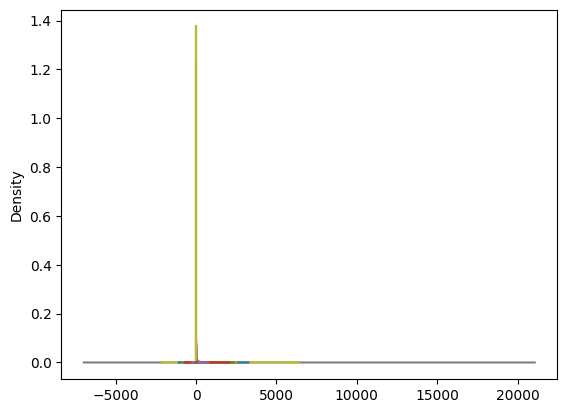

In [15]:
X_train.plot.kde(legend= False)

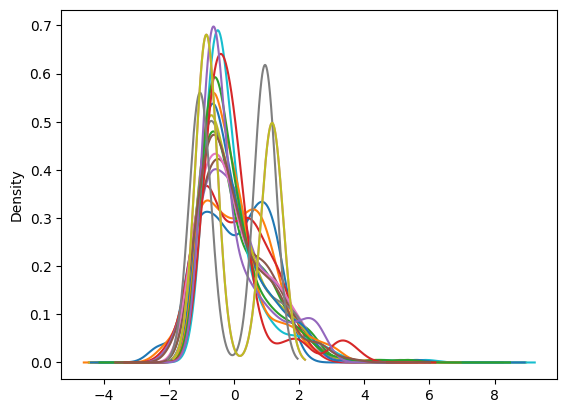

In [11]:
# Lets first standardize using numpy

xtr_copy=X_train.copy()
xte_copy=X_test.copy()

x_mean=xtr_copy.mean()
x_std=xtr_copy.std()

xtr_copy=(xtr_copy-x_mean)/x_std
xte_copy=(xte_copy-x_mean)/x_std

# Now lets plot
pd.DataFrame(xtr_copy, columns=X_train.columns).plot.kde(legend=False)
plt.show()


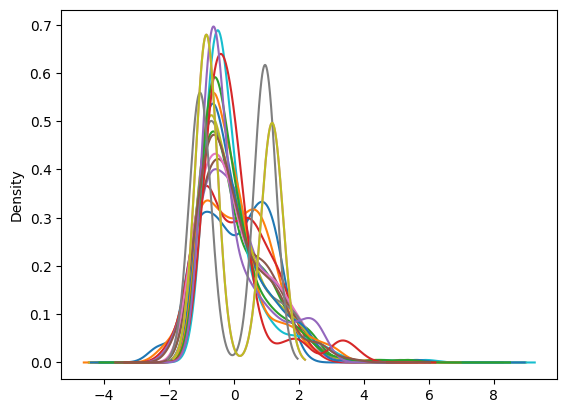

In [16]:
# Standardize the data
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

pd.DataFrame(X_train_scaled, columns =  X_train.columns).plot.kde(legend=False)
plt.show()

In [20]:
# Now train the model

lr=LinearRegression()
lr.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
coef_df =  pd.DataFrame(lr.coef_, index = X_train.columns, columns = ['COEF- Linear Regression'])
coef_df 

,COEF- Linear Regression
AtBat,-259.591129
Hits,136.304897
HmRun,10.846885
Runs,83.595299
RBI,31.975653
Walks,71.118902
Years,-50.437436
CAtBat,-274.726160
CHits,285.994816
CHmRun,-109.137141


In [22]:
# Regularization - Lasso Regression
lasso=Lasso(alpha=1)
lasso.fit(X_train_scaled,y_train)



,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [23]:
coef_df['COEF- Lasso'] =  lasso.coef_
coef_df

,COEF- Linear Regression,COEF- Lasso
AtBat,-259.591129,-258.732502
Hits,136.304897,150.107696
HmRun,10.846885,0.000000
Runs,83.595299,76.059540
RBI,31.975653,41.597206
Walks,71.118902,67.132574
Years,-50.437436,-67.336795
CAtBat,-274.726160,-0.000000
CHits,285.994816,164.711114
CHmRun,-109.137141,-46.052985


In [24]:
y_pred_train_lr=lr.predict(X_train_scaled)
y_pred_test_lr=lr.predict(X_test_scaled)

y_pred_train_lasso=lasso.predict(X_train_scaled)
y_pred_test_lasso=lasso.predict(X_test_scaled)

In [25]:
# Display Evaluation Results

# Display Evaluation Results

 

print(f'MSE Train Linear Regression :  {mean_squared_error(y_train, y_pred_train_lr):.4f}')

print(f'RMSE Train Linear Regression :  {np.sqrt(mean_squared_error(y_train, y_pred_train_lr)):.4f}')

print(f'MAE Train Linear Regression :  {mean_absolute_error(y_train, y_pred_train_lr):.4f}')

print(f'R2 Train Linear Regression :  {r2_score(y_train, y_pred_train_lr):.4f}')

print("-"* 50)

 

 

 

print(f'MSE Test Linear Regression :  {mean_squared_error(y_test, y_pred_test_lr):.4f}')

print(f'RMSE Test Linear Regression :  {np.sqrt(mean_squared_error(y_test, y_pred_test_lr)):.4f}')

print(f'MAE Test Linear Regression :  {mean_absolute_error(y_test, y_pred_test_lr):.4f}')

print(f'R2 Test Linear Regression :  {r2_score(y_test, y_pred_test_lr):.4f}')

print("-"* 50)

print(f'MSE Train Lasso Regression :  {mean_squared_error(y_train, y_pred_train_lasso):.4f}')

print(f'RMSE Train Lasso Regression :  {np.sqrt(mean_squared_error(y_train, y_pred_train_lasso)):.4f}')

print(f'MAE Train Lasso Regression :  {mean_absolute_error(y_train, y_pred_train_lasso):.4f}')

print(f'R2 Train Lasso Regression :  {r2_score(y_train, y_pred_train_lasso):.4f}')

print("-"* 50)

 

 

print(f'MSE Test Lasso Regression :  {mean_squared_error(y_test, y_pred_test_lasso):.4f}')

print(f'RMSE Test Lasso Regression :  {np.sqrt(mean_squared_error(y_test, y_pred_test_lasso)):.4f}')

print(f'MAE Test Lasso Regression :  {mean_absolute_error(y_test, y_pred_test_lasso):.4f}')

print(f'R2 Test Lasso Regression :  {r2_score(y_test, y_pred_test_lasso):.4f}')


MSE Train Linear Regression :  81377.5134
RMSE Train Linear Regression :  285.2674
MAE Train Linear Regression :  208.5556
R2 Train Linear Regression :  0.4431
--------------------------------------------------
MSE Test Linear Regression :  124964.9042
RMSE Test Linear Regression :  353.5038
MAE Test Linear Regression :  256.5876
R2 Test Linear Regression :  0.4230
--------------------------------------------------
MSE Train Lasso Regression :  82048.9209
RMSE Train Lasso Regression :  286.4418
MAE Train Lasso Regression :  209.0396
R2 Train Lasso Regression :  0.4385
--------------------------------------------------
MSE Test Lasso Regression :  125494.8769
RMSE Test Lasso Regression :  354.2526
MAE Test Lasso Regression :  255.5776
R2 Test Lasso Regression :  0.4205


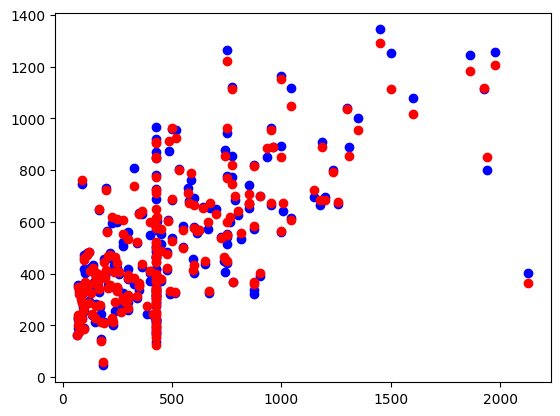

In [27]:
# Visualize the predictions 

plt.scatter(y_train, y_pred_train_lr, color='blue', label='Train Predictions')
plt.scatter(y_train,y_pred_train_lasso,color='red', label='Lasso Predictions')

#### Ridge Regression

In [28]:
from sklearn.linear_model import Ridge,RidgeCV

In [ ]:
ridge=Ridge(alpha=1)
ridge.fit(X_train_scaled,y_train)


,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [ ]:
# Evaluate Ridge Regression

y_pred_train_ridge=ridge.predict(X_train_scaled)


## Model Optimization

In [30]:
ridge.get_params()

{'alpha': 1,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [33]:
# Implement GridSearch with Cross Validation


from sklearn.model_selection import GridSearchCV,KFold

kf=KFold(n_splits=5,shuffle=True,random_state=42)

param_grid={'alpha':np.arange(0.1,1,0.1),'random_state':[1,2]}

model=Ridge()



In [34]:
search=GridSearchCV(model,param_grid,cv=kf,scoring='r2')
search.fit(X_train_scaled,y_train)

,estimator,Ridge()
,param_grid,"{'alpha': array([0.1, 0....7, 0.8, 0.9]), 'random_state': [1, 2]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.9)


In [35]:
print("Best Parameters: ",search.best_params_)
print("Best Score: ",search.best_score_)

Best Parameters:  {'alpha': np.float64(0.9), 'random_state': 1}
Best Score:  0.30944508576050167


## Sklearn Pipeline

In [ ]:
# libs
import pandas as pd
import numpy as np
import sklearn.model_selection import train_test_split,KFold,cross_val_score